Creates the flowchart used in my GRFP research proposal

Illustrates the current B12 state of the art then the two new major improvements, Himansh's Nbody ICs and Ethan's SMUGGLE run, and then the goal which is my work

This is a one off piece of code that isn't intended for future use which would require implementation in amms-core plotting and version stamping

This is also written to be run locally and is missing the more generic codes. This is purely just stitching together premade plots

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

FIG_DIR = Path("/home/zvladimir/lmcsmcmw/figures")

In [2]:
def draw_panel(ax, spec):
    if spec["path"] is not None and Path(spec["path"]).exists():
        ax.imshow(plt.imread(spec["path"]), cmap="gray")
    else:
        ax.add_patch(Rectangle((0.03, 0.03), 0.94, 0.94, fill=False, linestyle="--", linewidth=1.5, transform=ax.transAxes))
        ax.text(0.5, 0.5, "placeholder", ha="center", va="center", transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(spec["title"], fontsize=10)
    ax.set_xlabel(spec["caption"], fontsize=8, style="italic")

In [ ]:
PANELS = {
    "baseline": dict(
        path=FIG_DIR / "sfr_slice_4-7.png",
        title="Current state of the art",
        caption="Besla et al. 2012 Model 2",
    ),
    "nbody": dict(
        path=FIG_DIR / "clouds_ra_dec_simulated.jpg",
        title="Demonstrated: higher-res N-body ICs",
        caption="Rathore+In prep?"
    ),
    "ism": dict(
        path="/home/zvladimir/lmcsmcmw/figures/jahn2023_smuggle-1.png",
        title="Demonstrated: SMUGGLE ISM model",
        caption="Jahn+2023, SMC analog",
    ),
    "goal": dict(
        path="/home/zvladimir/lmcsmcmw/figures/mazzi2021_sfr.png",
        title="Produce: SFR maps matching observations",
        caption="Mazzi+2024 has provided extremely high resolution SFR maps With high-res N-body + SMUGGLE",
    ),
}

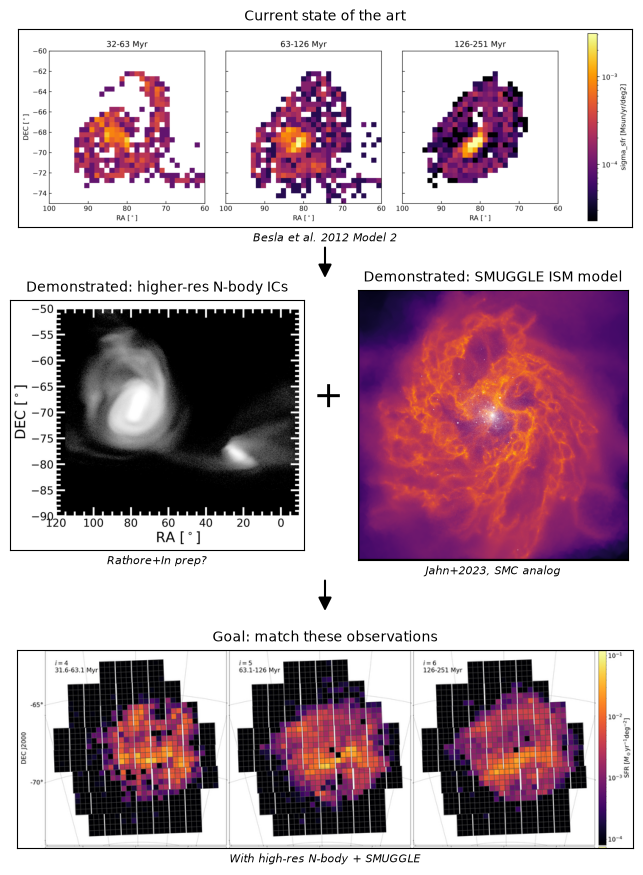

In [30]:
fig = plt.figure(figsize=(7, 9))

# top: baseline, full width, short (matches the wide row-of-panels shape)
ax_a    = fig.add_axes([0.05, 0.74, 0.90, 0.22])
# middle: nbody + ism side by side (still roughly square images)
ax_b    = fig.add_axes([0.05, 0.37, 0.42, 0.30])
ax_c    = fig.add_axes([0.53, 0.37, 0.42, 0.30])
# bottom: goal, full width, short
ax_goal = fig.add_axes([0.05, 0.05, 0.90, 0.22])

for ax, key in [(ax_a, "baseline"), (ax_b, "nbody"), (ax_c, "ism"), (ax_goal, "goal")]:
    draw_panel(ax, PANELS[key])

fig.text(0.505, 0.55, "+", fontsize=26, ha="center", va="center")

arrow_kw = dict(arrowstyle="-|>", mutation_scale=20, linewidth=1.5, color="black", transform=fig.transFigure)

fig.patches.append(FancyArrowPatch((0.50, 0.72), (0.50, 0.68), **arrow_kw))
fig.patches.append(FancyArrowPatch((0.50, 0.35), (0.50, 0.31), **arrow_kw))

fig.savefig(FIG_DIR / "grfp_flowchart_draft.png", dpi=300)